In [4]:
from escripts import eplots
from escripts import eMCMC
from escripts import edata
import corner

In [2]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_low_z.txt',
              '/Users/eb35267/Desktop/code/home/data/Donnan24_limit_z.txt']
data_labels = ['Bouwens+21 (HST)', 'Donnan+24 (JWST)']
sorted_data = edata.get_sorted(file_names, data_labels)

In [3]:
params = eMCMC.build_param_data({'dsigdz': {'fit': True}, 'dsigdlogM':{'fit':True}, 'dlogMcdz':{'fit':True}})
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [4]:
const_stochasticity = [0.549, -0.947, 12.059, 0, -0.745, 0.3, 0, 0]
bf_model = [0.569, -0.7, 12.204, 0.094, -0.718, 0.276, 0.265, -0.133]

In [5]:
comparison_fits = {'fit': [bf_model],
                   'label': ['evolving stochasticity'],
                   'color': [eplots.periwinkle],
                   'linestyle': ['solid'],
                   'linewidth': [4]}

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:252: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5, zorder = dat_zorder)


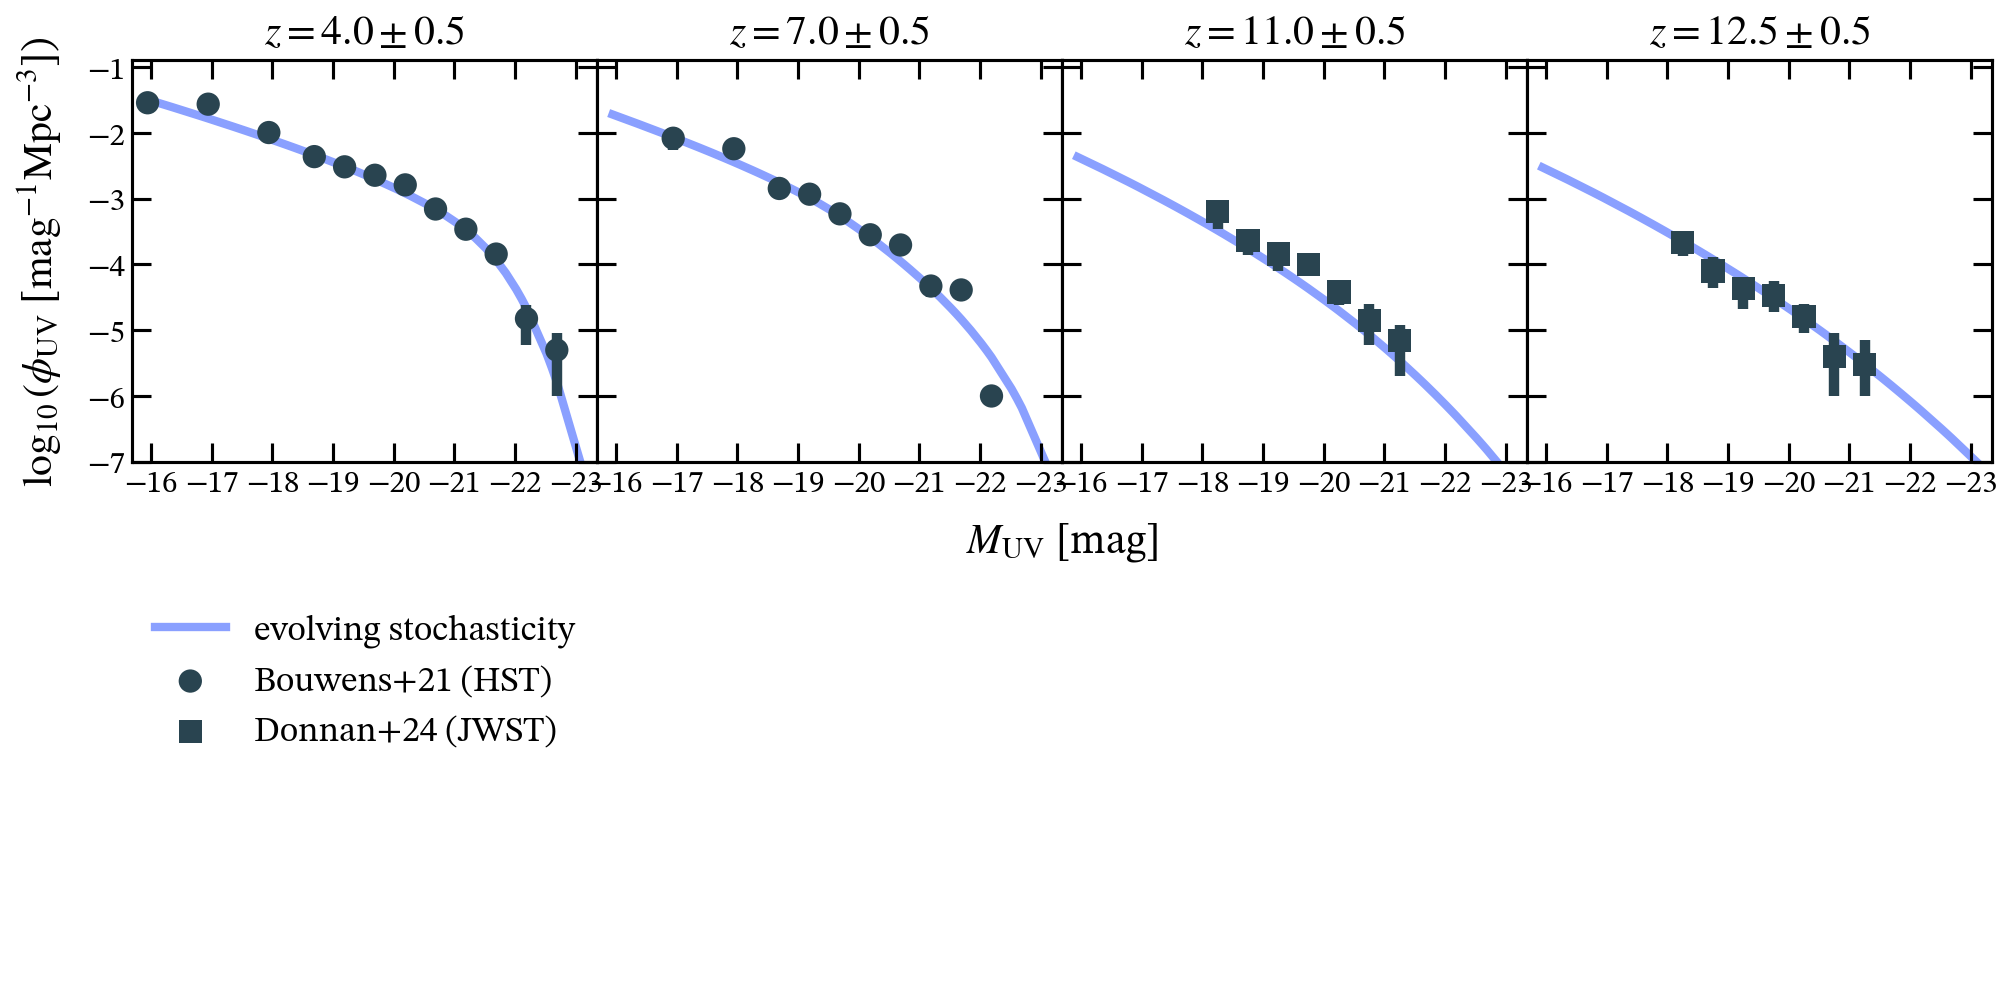

In [6]:
evolving_UVLF = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_dict = comparison_fits, ncols = 4,  
               show_chi2 = False, z_plot=[4, 7, 11, 12.5])

In [7]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/coruña/uvlf.png', dpi = 300)

In [14]:
comparison_fits = {'fit': [const_stochasticity],
                   'label': [r'constant stochasticity'],
                   'color': [eplots.orange],
                   'linestyle': ['solid'],
                   'linewidth': [4]}

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:252: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5, zorder = dat_zorder)


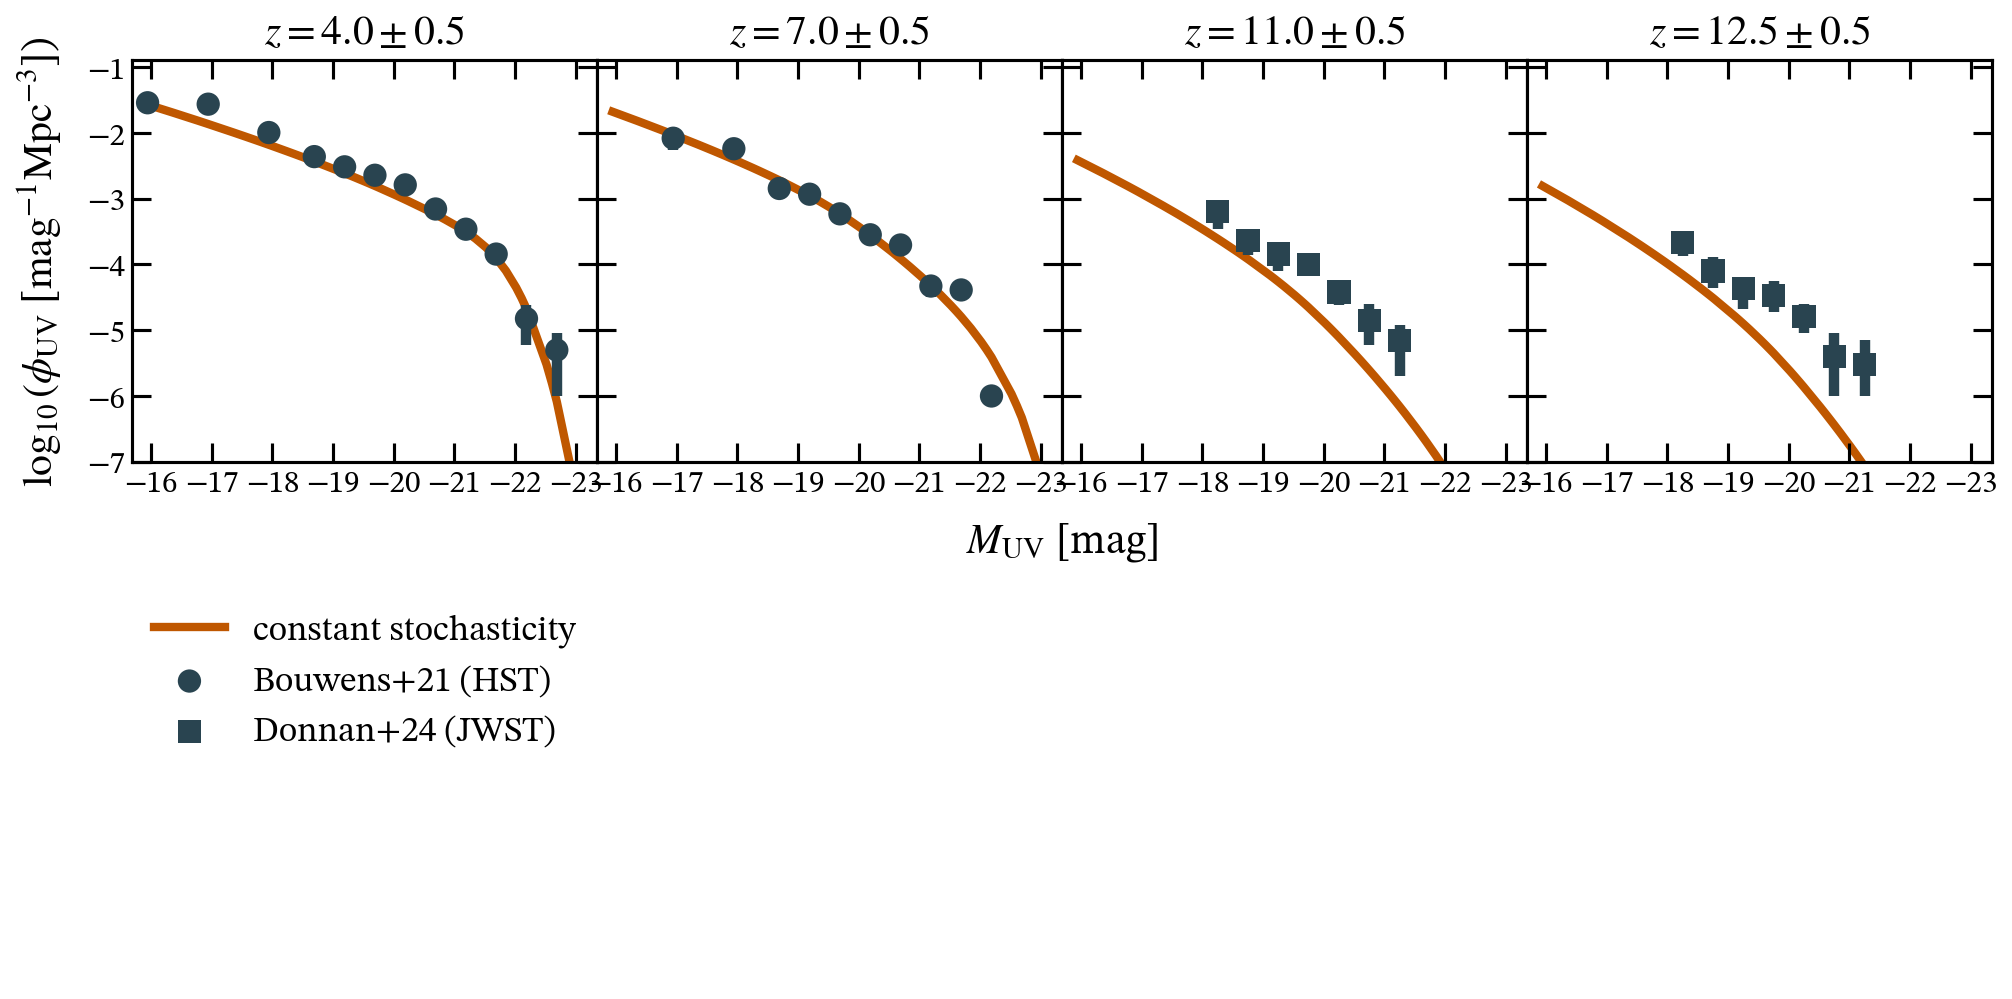

In [15]:
evolving_UVLF = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_dict = comparison_fits, ncols = 4,  
               show_chi2 = False, z_plot=[4, 7, 11, 12.5])

In [13]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/coruña/const_sig_uvlf.png', dpi=300)

In [9]:
samples_best_fit = np.loadtxt('/Users/eb35267/Desktop/code/chains/flattened_best_fit.txt')

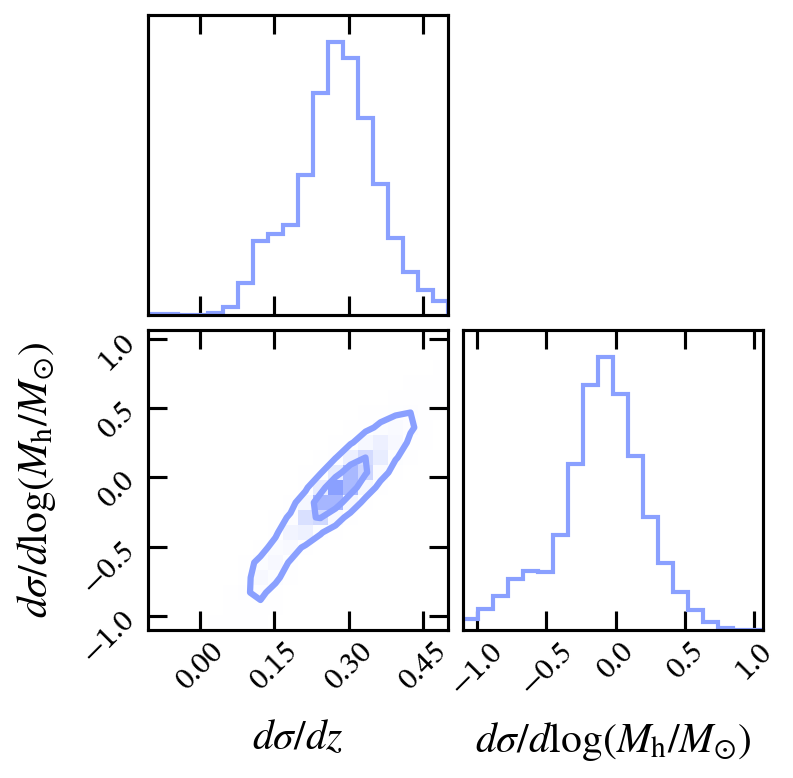

In [25]:
corner_plot = corner.corner(samples_best_fit[:, [-2, -1]], labels= [r'$d\sigma/dz$', r'$d\sigma/d\log(M_{\rm{h}}/M_{\odot})$'], 
                            color = eplots.periwinkle, plot_contours = True, plot_datapoints = False, 
                            hist_kwargs={'linewidth': 2, 'density': True, 'linestyle': 'solid'}, 
                            levels = (0.393, 0.864))

In [26]:
corner_plot.axes[2].set_xlim(-0.5, 0.5)

(-0.5, 0.5)

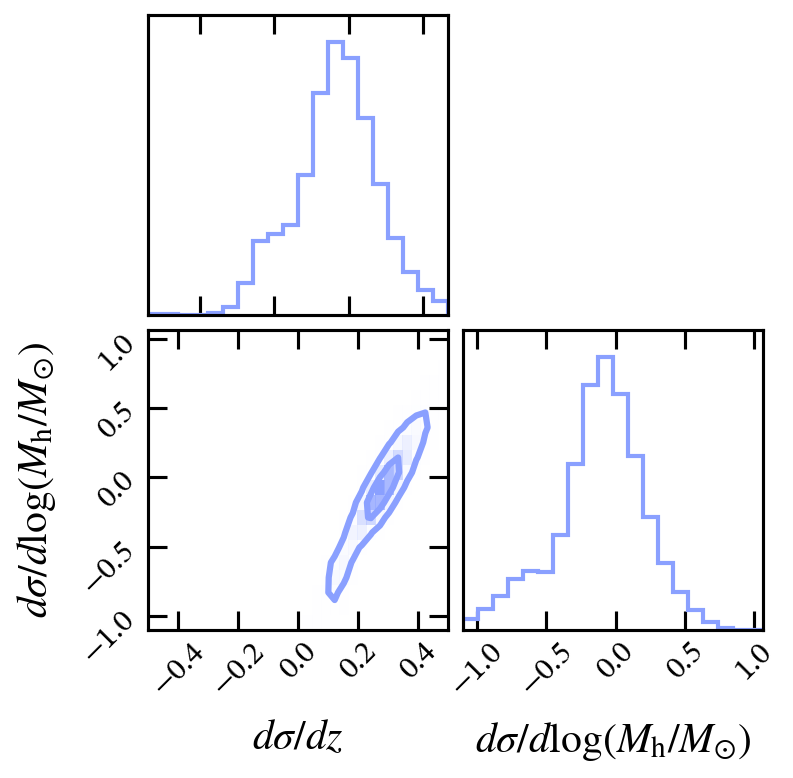

In [27]:
corner_plot

In [28]:
corner_plot.savefig('/Users/eb35267/Desktop/figures/coruña/corner.png', dpi = 300)

In [37]:
just_HST = [0.757, -0.793, 12.343, 0.114, -0.728, 0.822, 0.004, -0.695]

In [38]:
comparison_fits = {'fit': [just_HST],
                   'label': [r'pre-JWST model'],
                   'color': [eplots.yellow],
                   'linestyle': ['solid'],
                   'linewidth': [4]}

/Users/eb35267/Desktop/code/repos/Zeus21/zeus21/UVLFs.py:33: RuntimeWarning: divide by zero encountered in log10
  MUVtab = 51.63 - 2.5 * np.log10(LUVtab) #AB magnitude
/Users/eb35267/Desktop/code/home/escripts/eplots.py:252: RuntimeWarning: invalid value encountered in log10
  ax.vlines(xdat, np.clip(np.log10(ydat - yerr_lower), -100, 100), np.clip(np.log10(ydat + yerr_upper), -100, 100), ls = '-', colors = navy, linewidth =5, zorder = dat_zorder)


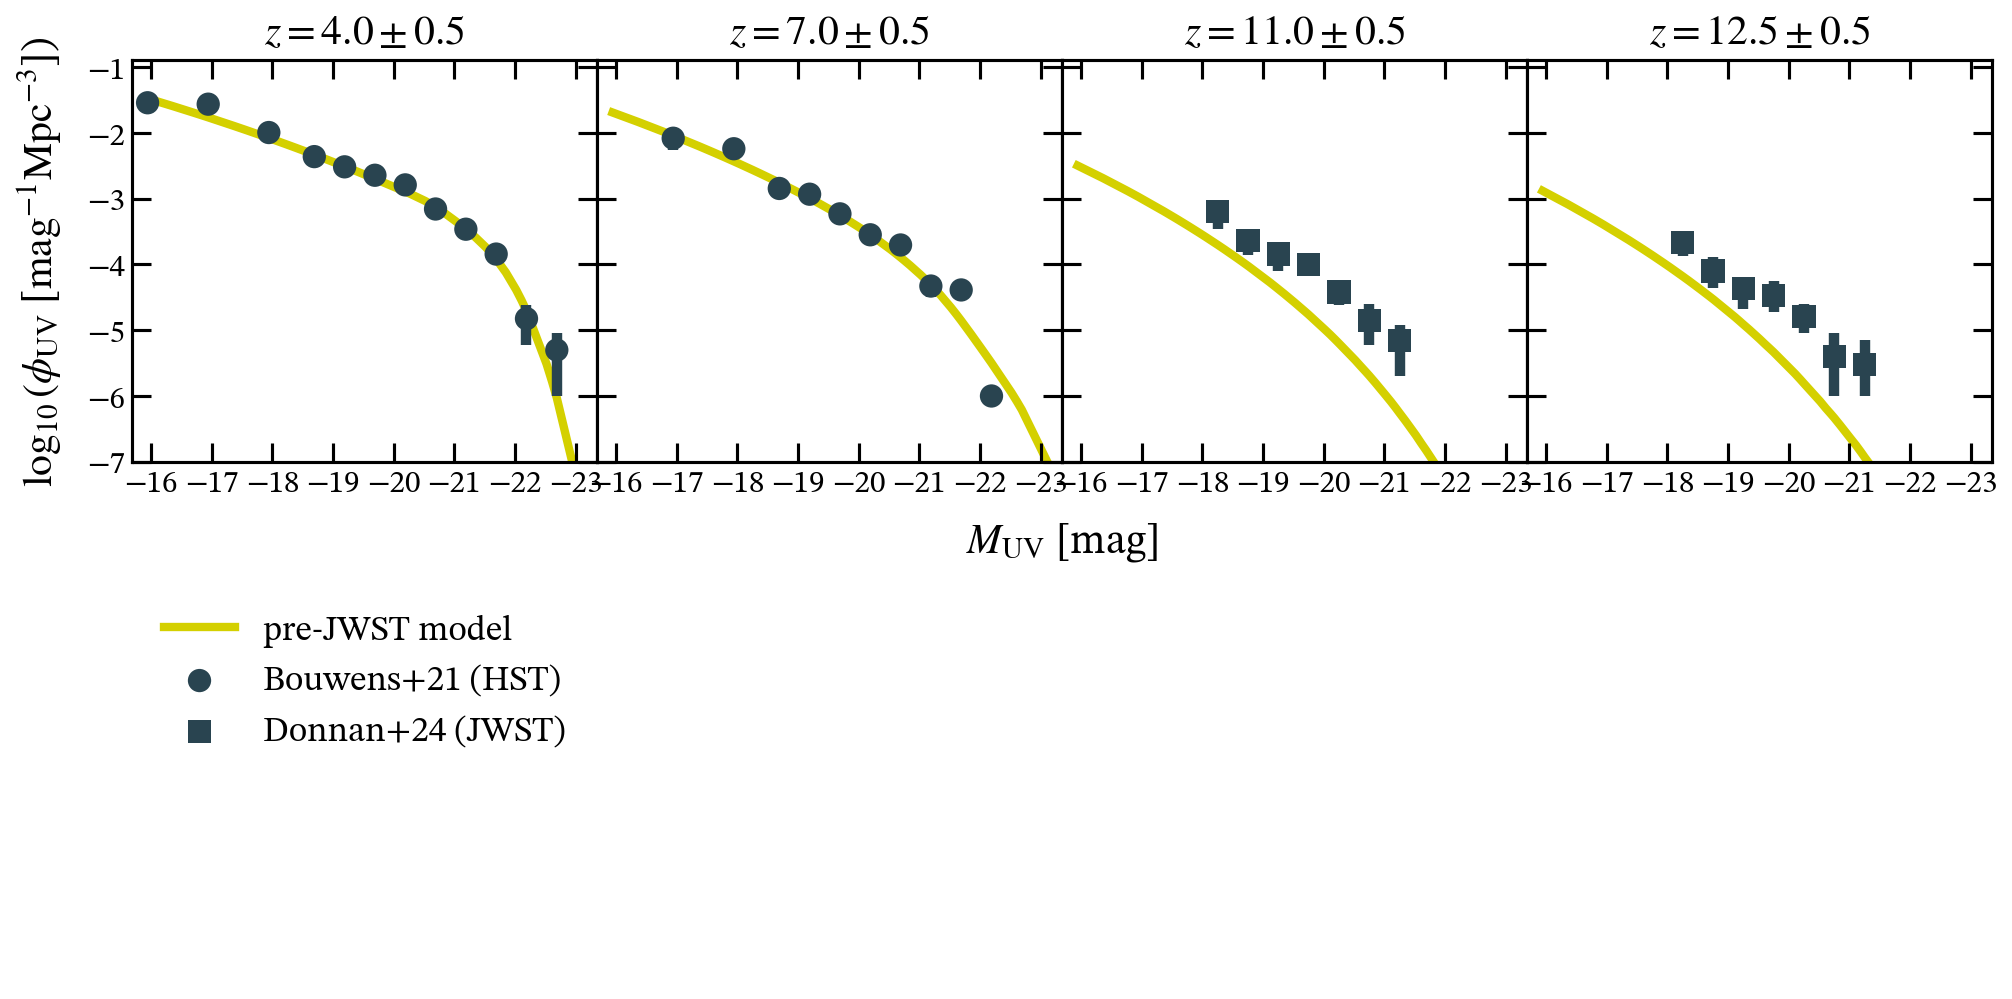

In [39]:
evolving_UVLF = eplots.evolving_UVLF_fit(my_UVLF, plot_from_chain = False, comparison_dict = comparison_fits, ncols = 4,  
               show_chi2 = False, z_plot=[4, 7, 11, 12.5])

In [40]:
evolving_UVLF.savefig('/Users/eb35267/Desktop/figures/coruña/pre-JWST_UVLF.png', dpi = 300)

red: #b84557
turquoise: #03abc1
yellow: #d4d000
navy: #294450
orange: #bf5700
green: #719920
periwinkle: #8aa0ff


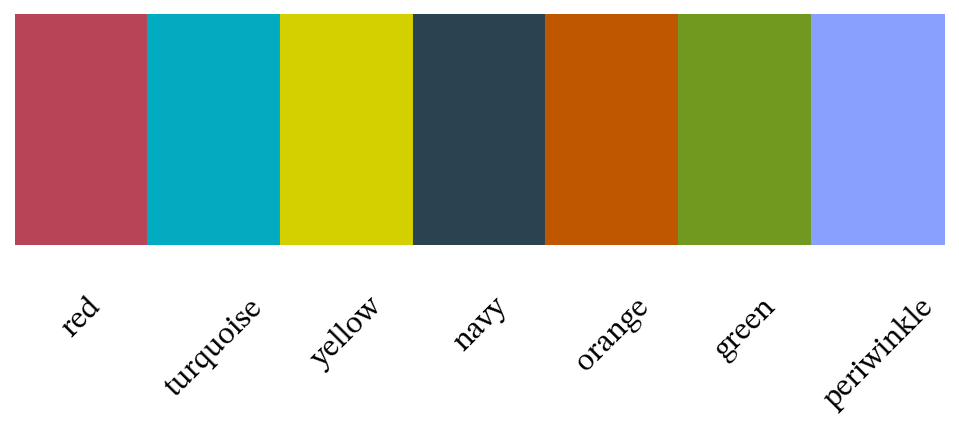

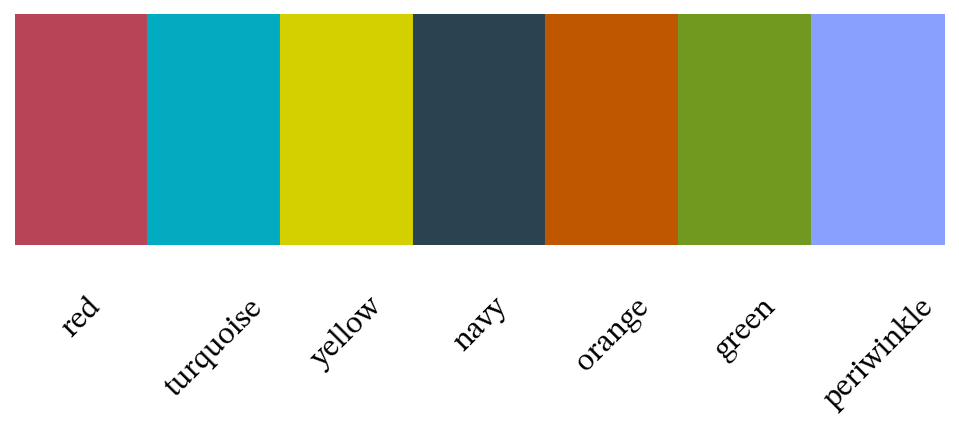

In [5]:
eplots.plot_colors()

In [6]:
from astropy import units as u

In [36]:
c = 36e3 * u.km
r = c/(2*np.pi)

In [37]:
V = 4/3 * np.pi * r**3

In [38]:
V

<Quantity 7.87873524e+11 km3>

In [39]:
rho = 1 * u.g/u.cm**3

In [46]:
M = (rho*V).to(u.g)

In [47]:
M

<Quantity 7.87873524e+26 g>

In [16]:
np.arctan(12.63/100)

0.12563478908080963

In [17]:
d = 3.4e6 * u.lyr

In [21]:
v = 100 *u.km/(1e-3*u.s)

In [23]:
t = (d/v).to(u.Gyr)

In [24]:
t

<Quantity 0.01019294 Gyr>

In [26]:
4/3 * np.pi * 5729.58**3

787874369149.1417

In [42]:
36**3/(6*np.pi**2)

787.8735240028186